In [ ]:
#!pip install geopy
#!pip install tensorflow

In [5]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
from geopy.distance import geodesic

# ML and Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

#Visualization
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')  # Suppresses warning messages in the output

In [7]:
# 1. Simulate Delivery Data
def simulate_delivery_data(num_records=100_000):
    def haversine_distance(lat1, lon1, lat2, lon2):
        return geodesic((lat1, lon1), (lat2, lon2)).km

    pickup_times = [
        datetime.now() - timedelta(days=random.randint(1, 365), minutes=random.randint(1, 60))
        for _ in range(num_records)
    ]

    data = {
        'order_id': [f'ORD_{i}' for i in range(num_records)],
        'rider_id': [f'RIDER_{random.randint(1, 500)}' for _ in range(num_records)],
        'restaurant_lat': np.random.uniform(17.3, 17.5, num_records),
        'restaurant_lon': np.random.uniform(78.3, 78.6, num_records),
        'customer_lat': np.random.uniform(17.3, 17.5, num_records),
        'customer_lon': np.random.uniform(78.3, 78.6, num_records),
        'pickup_time': pickup_times,
        'actual_travel_time_minutes': np.random.normal(30, 10, num_records).clip(5, 60),
        'scheduled_travel_time_minutes': np.random.normal(25, 8, num_records).clip(5, 50),
        'num_items': np.random.randint(1, 10, num_records),
        'order_value_usd': np.random.uniform(5, 50, num_records),
        'restaurant_type': random.choices(['fast_food', 'fine_dining', 'cafe', 'dessert', 'street_food'], k=num_records),
        'weather_conditions': random.choices(['clear', 'rainy', 'cloudy', 'stormy'], weights=[0.5, 0.2, 0.2, 0.1], k=num_records),
        'traffic_level': random.choices(['low', 'moderate', 'high', 'severe'], weights=[0.3, 0.4, 0.2, 0.1], k=num_records),
        'rider_avg_speed_kmph': np.random.normal(20, 5, num_records).clip(10, 40),
        'rider_break_frequency_hr': np.random.normal(0.5, 0.2, num_records).clip(0, 1),
        'rider_acceptance_rate': np.random.uniform(0.7, 1.0, num_records),
        'rider_rating': np.random.uniform(3.0, 5.0, num_records),
        'rider_shift_hours': np.random.uniform(0, 12, num_records)
    }

    df = pd.DataFrame(data)

# Feature Engineering
    df['pickup_hour'] = pd.to_datetime(df['pickup_time']).dt.hour
    df['pickup_dayofweek'] = pd.to_datetime(df['pickup_time']).dt.dayofweek
    df['pickup_month'] = pd.to_datetime(df['pickup_time']).dt.month
    df['pickup_dayofyear'] = pd.to_datetime(df['pickup_time']).dt.dayofyear

    df['route_distance_km'] = df.apply(lambda row: haversine_distance(
        row['restaurant_lat'], row['restaurant_lon'],
        row['customer_lat'], row['customer_lon']), axis=1)

    df['was_late'] = (df['actual_travel_time_minutes'] > df['scheduled_travel_time_minutes']).astype(int)

    df['actual_delivery_time'] = df.apply(lambda row: row['pickup_time'] + timedelta(minutes=row['actual_travel_time_minutes']), axis=1)
    df['scheduled_delivery_time'] = df.apply(lambda row: row['pickup_time'] + timedelta(minutes=row['scheduled_travel_time_minutes']), axis=1)

    df = pd.get_dummies(df, columns=['weather_conditions'], prefix='weather')

    # Real-time sample print
    realtime_data = {
        'order_id': 'ORD_X',
        'rider_id': 'RIDER_Y',
        'current_lat': 17.40,
        'current_lon': 78.45,
        'timestamp': datetime.now()
    }

    print("Simulated Real-time Data Example:")
    print(realtime_data)

    return df


In [8]:
# Generate data
df = simulate_delivery_data(100_000)

# Define Features and Target
excluded = [
    'order_id', 'rider_id', 'pickup_time',
    'actual_delivery_time', 'scheduled_delivery_time',
    'actual_travel_time_minutes', 'scheduled_travel_time_minutes',
    'restaurant_lat', 'restaurant_lon',
    'customer_lat', 'customer_lon'
]

target = 'actual_travel_time_minutes'
features = [col for col in df.columns if col not in excluded]

X = df[features].copy()
y = df[target]

Simulated Real-time Data Example:
{'order_id': 'ORD_X', 'rider_id': 'RIDER_Y', 'current_lat': 17.4, 'current_lon': 78.45, 'timestamp': datetime.datetime(2025, 12, 10, 16, 49, 3, 228191)}


In [9]:
X

,num_items,order_value_usd,restaurant_type,traffic_level,rider_avg_speed_kmph,rider_break_frequency_hr,rider_acceptance_rate,rider_rating,rider_shift_hours,pickup_hour,pickup_dayofweek,pickup_month,pickup_dayofyear,route_distance_km,was_late,weather_clear,weather_cloudy,weather_rainy,weather_stormy
0,3,12.633157,street_food,high,29.893229,0.515195,0.822778,3.350484,1.821404,16,1,12,343,13.751962,1,True,False,False,False
1,3,23.895257,fast_food,moderate,23.195091,0.229592,0.804251,3.656802,2.353777,16,2,7,190,17.757248,1,False,False,True,False
2,2,25.106182,fine_dining,low,29.009473,0.513974,0.961954,4.804548,0.252132,16,3,4,100,9.347258,1,True,False,False,False
3,8,45.792932,fine_dining,moderate,22.026950,0.654034,0.789681,3.669792,9.646169,16,3,9,247,7.998100,1,False,False,True,False
4,5,14.294392,street_food,moderate,29.413745,0.334931,0.906593,4.411760,3.287870,16,4,12,355,16.118593,1,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,6,9.764979,fast_food,high,18.655968,0.462215,0.777363,4.941821,4.214894,16,2,10,288,22.624592,1,True,False,False,False
99996,1,26.806246,fast_food,low,24.002702,0.311868,0.874129,3.649331,4.079905,16,0,6,181,17.472436,0,False,True,False,False
99997,8,18.478434,fast_food,moderate,18.541149,0.572131,0.745907,3.535529,7.409251,16,2,10,274,18.868745,1,False,True,False,False
99998,8,22.220012,fine_dining,moderate,24.712817,0.000000,0.714644,3.190446,11.614763,15,0,12,342,15.570154,1,True,False,False,False


In [10]:
y

0        28.789638
1        28.163163
2        43.499266
3        38.297597
4        35.178621
           ...    
99995    26.674101
99996    23.566834
99997    37.554673
99998    49.380892
99999    21.088042
Name: actual_travel_time_minutes, Length: 100000, dtype: float64

# 2 - ETA Prediction Models

In [11]:
# Split data into 60, 20, 20%
# (60% for training, 20% for validation and 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

# Scale numerical features (example using StandardScaler)
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

# Create transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat',OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
    ]
)

# 6. Fit on training and transform all sets
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Check shape
print("X_train processed shape:", X_train_processed.shape)
print("y_train shape:", y_train.shape)

# Numerical and Categorical Columns
print()
print("Numerical Features:",numerical_cols)
print()
print("Categorical Features:",categorical_cols)
print()

X_train processed shape: (60000, 15)
y_train shape: (60000,)

Numerical Features: ['num_items', 'order_value_usd', 'rider_avg_speed_kmph', 'rider_break_frequency_hr', 'rider_acceptance_rate', 'rider_rating', 'rider_shift_hours', 'pickup_hour', 'pickup_dayofweek', 'pickup_month', 'pickup_dayofyear', 'route_distance_km', 'was_late']

Categorical Features: ['restaurant_type', 'traffic_level']



In [12]:
# Random Forest model
# Used to compute feature importance basis preprocessed data

feature_names = preprocessor.get_feature_names_out()

# Train Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_processed, y_train)

# Rank basis importance
importance = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

#View top features
print("\nTop 10 Features by Importance:")
print(feature_importance_df.head(10))

## Note: Model relies heavily on rider and route behavioural patterns.


Top 10 Features by Importance:
                          Feature  Importance
12                  num__was_late    0.369993
5               num__rider_rating    0.068095
6          num__rider_shift_hours    0.067978
1            num__order_value_usd    0.067411
4      num__rider_acceptance_rate    0.067409
11         num__route_distance_km    0.067063
3   num__rider_break_frequency_hr    0.066996
2       num__rider_avg_speed_kmph    0.066550
10          num__pickup_dayofyear    0.053065
0                  num__num_items    0.028362


In [13]:
## Multi-Layer Perceptron Model -- Baseline Model
def train_mlp(X_train, y_train, X_val, y_val, X_test, y_test, name="mlp_model"):
    mlp_model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])

    mlp_model.compile(
        optimizer='adam',
        loss='mean_squared_error',
        metrics=['mae']
    )

    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = mlp_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=32,
        verbose=1,
        callbacks=[early_stop]
    )

    test_loss, test_mae = mlp_model.evaluate(X_test, y_test)

    print(f"\n{name} Test MAE: {test_mae:.2f} minutes")

    return mlp_model, history


In [14]:
print("\n Training MLP Model:")
model, history = train_mlp(X_train_processed, y_train, X_val_processed, y_val, X_test_processed, y_test)


 Training MLP Model:
Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 394us/step - loss: 100.2749 - mae: 7.5570 - val_loss: 66.3102 - val_mae: 6.4970
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 349us/step - loss: 64.5514 - mae: 6.4176 - val_loss: 63.9499 - val_mae: 6.3971
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 353us/step - loss: 63.3571 - mae: 6.3590 - val_loss: 63.8360 - val_mae: 6.3828
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 361us/step - loss: 62.9091 - mae: 6.3331 - val_loss: 63.4969 - val_mae: 6.3553
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 354us/step - loss: 62.7820 - mae: 6.3288 - val_loss: 63.9889 - val_mae: 6.3805
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 408us/step - loss: 62.6610 - mae: 6.3261 - val_loss: 63.4704 - val_mae: 6.3715
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 353us/step - loss: 62.7209 - mae: 6.3223 - val_loss: 63.9496 - val_mae: 6.3740
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 361us/step - loss: 62.6919 - mae: 6.3245 - val_loss: 63.3752 - v

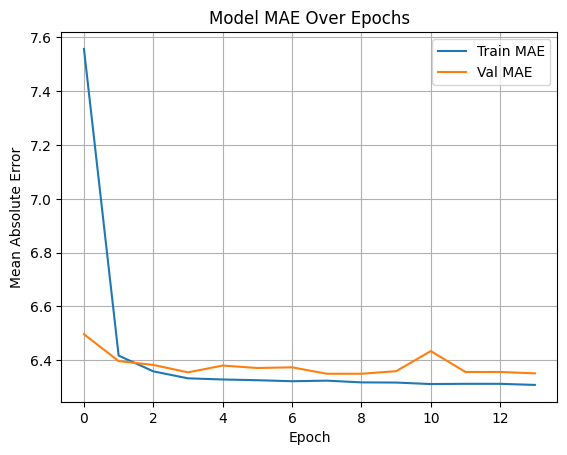

In [15]:
def plot_history(history):
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Val MAE')
    plt.title("Model MAE Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Mean Absolute Error")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history)

# Model is learning generalizable patterns
# No signs of over or underfitting
# Training stops when Val MAE flattens

In [16]:
## Basic Evaluation
y_pred = model.predict(X_test_processed).flatten()

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 165us/step
MAE: 6.294292498701207
RMSE: 7.892747954419982
R²: 0.3620772181009422


In [17]:
## MLP Retrained on top features

top_n = 10
top_features = feature_importance_df['Feature'].head(top_n).tolist()

feature_names = preprocessor.get_feature_names_out()
top_indices = [i for i, name in enumerate(feature_names) if name in top_features]

X_train_top = X_train_processed[:, top_indices]
X_val_top = X_val_processed[:, top_indices]
X_test_top = X_test_processed[:, top_indices]

model_top, history_top = train_mlp(
    X_train_top, y_train,
    X_val_top, y_val,
    X_test_top, y_test,
    name=f"MLP_Top_{top_n}_Features"
)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 377us/step - loss: 105.8746 - mae: 7.7026 - val_loss: 66.3140 - val_mae: 6.5096
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 348us/step - loss: 64.4779 - mae: 6.4122 - val_loss: 64.2674 - val_mae: 6.4098
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 357us/step - loss: 63.1695 - mae: 6.3468 - val_loss: 63.7687 - val_mae: 6.3682
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 356us/step - loss: 62.8812 - mae: 6.3304 - val_loss: 63.7724 - val_mae: 6.3634
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 354us/step - loss: 62.6362 - mae: 6.3219 - val_loss: 63.5195 - val_mae: 6.3821
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 350us/step - loss: 62.6511 - mae: 6.3255 - val_loss: 63.2615 - val_mae: 6.3606
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 351us/step - loss: 62.6145 - mae: 6.3175 - val_loss: 63.1592 - val_mae: 6.3524
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 347us/step - loss: 62.4956 - mae: 6.3121 - val_loss: 63.6297 - val_mae: 6.3628
Epoch 9

In [18]:
print(f"\nTraining with top {top_n} Features:")
for i, fname in enumerate(top_features):
    clean_name = str(fname).replace('num__', '').replace('cat__', '')
    print(f"{i+1}. {clean_name}")


Training with top 10 Features:
1. was_late
2. rider_rating
3. rider_shift_hours
4. order_value_usd
5. rider_acceptance_rate
6. route_distance_km
7. rider_break_frequency_hr
8. rider_avg_speed_kmph
9. pickup_dayofyear
10. num_items


## <center> 2.2.3 MLP and Business Impact </center>

In [19]:
# Predict on test data
y_pred = model_top.predict(X_test_top).flatten()  # flatten to match shape of y_test

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 166us/step


In [20]:
## (A) On-time Delivery Rate (+/- 5 minutes)

errors = np.abs(y_pred - y_test)
on_time = (errors <= 5).sum()
on_time_rate = on_time / len(y_test) * 100

print(f"On Time Delivery Rate: {on_time_rate:.2f}%")


On Time Delivery Rate: 47.75%


In [21]:
## (B) Late Delivery Risk
# 'scheduled_delivery_time' - when delivery was promised
# 'actual_delivery_time' - annual time taken
# 'y_pred' - predicted delivery time from MLP model

# Create df_test as the test subset of full dataframe, aligned with y_pred -- i.e. matches y_pred with the right rows from original data frame
df_test = df.loc[X_test.index]

# Compute lateness using test data only
actual_lateness = df_test['actual_travel_time_minutes'] - df_test['scheduled_travel_time_minutes']
predicted_lateness = y_pred - df_test['scheduled_travel_time_minutes']

# Risky Late Delivery = Predicted early (<=5) but actually late (>5)
late_risk_mask = (predicted_lateness <= 5) & (actual_lateness > 5)
late_risk_pct = late_risk_mask.sum() / len(y_test) * 100

print(f"Late Risk Percentage: {late_risk_pct:.2f}%")


Late Risk Percentage: 5.79%


In [22]:
## (C) ETA Confidence Interval / Spread

residuals = y_pred - y_test
std_dev = np.std(residuals)
lower = np.percentile(residuals, 2.5)
upper = np.percentile(residuals, 97.5)

print(f"ETA Spread (Std Dev): {std_dev:.2f} minutes")
print(f"95% Confidence Interval (Two-Tailed): [{lower:.2f},{upper:.2f}]")

ETA Spread (Std Dev): 7.90 minutes
95% Confidence Interval (Two-Tailed): [-16.32,15.04]


## ML Predictions used in Rule-based AI Agents
A) Intelligent Rider Reassignment Agent
B) Contextual Customer Communication Agent
C) Proactive Fraud Detection Agent

In [23]:
## A) Intelligent Rider Reassignment Agent - Suggest a better rider if predicted ETA is too high

def rider_reassignment_agent(df, y_pred, threshold=5):
    df = df.copy()
    df['predicted_eta'] = y_pred
    df['scheduled_eta'] = df['scheduled_travel_time_minutes']

    # Flag deliveres that are predicted to be late by more than threshold
    df['risk_of_delay'] = df['predicted_eta'] > (df['scheduled_eta'] + threshold)

    # Reassignment suggestion
    df['reassignment_action'] = df['risk_of_delay'].apply(
        lambda x: "Suggest reassignment" if x else "No action"
    )

    return df[['rider_id','predicted_eta','scheduled_eta','risk_of_delay','reassignment_action']]


In [24]:
## B) Contextual Customer Communication Agent - Suggest messages to send to customers based on predicted delays

def customer_comm_agent(df, y_pred, y_test):
    df = df.copy()
    df['predicted_eta'] = y_pred
    df['actual_eta'] = y_test.values
    df['residual'] = df['predicted_eta'] - df['actual_eta']

    def generate_message(row):
        if row['residual'] > 5:
            return f"Your order may be delayed due to traffic/weather. ETA: {row['predicted_eta']:.0f} mins."
        elif row['residual'] < -5:
            return f"Your order may arrive early. ETA: {row['predicted_eta']:.0f} mins."
        else:
            return f"Your delivery is on time. ETA: {row['predicted_eta']:.0f} mins."

    df['customer_message'] = df.apply(generate_message, axis=1)

    return df[['rider_id', 'predicted_eta', 'actual_eta', 'residual', 'customer_message']]

In [25]:
## C) Proactive Fraud Detection Agent - Flag deliveries where ETA looks suspicious or manipulated

def fraud_detection_agent(df, y_pred, y_test):
    df = df.copy()
    df['predicted_eta'] = y_pred
    df['actual_eta'] = y_test.values
    df['residual'] = df['predicted_eta'] - df['actual_eta']

    z_scores = (df['residual'] - df['residual'].mean()) / df['residual'].std()
    df['eta_anomaly_score'] = z_scores.abs()
    df['fraud_flag'] = df['eta_anomaly_score'] > 3 # 3 standard deviations from mean

    return df[['rider_id', 'predicted_eta', 'actual_eta', 'eta_anomaly_score', 'fraud_flag']]


In [26]:
# Test data frame retrieved from original df
df_test = df.iloc[X_test.index].copy()

In [27]:
# Predicted and actual observations added
df_test['predicted_eta'] = y_pred
df_test['actual_eta'] = y_test.values

In [28]:
# Step 3: Run agents only on this test set
reassign_df = rider_reassignment_agent(df_test, y_pred, y_test)
comm_df = customer_comm_agent(df_test, y_pred, y_test)
fraud_df = fraud_detection_agent(df_test, y_pred, y_test)